# Qwen Image Ranking Exploration

In [12]:
# import libraries
import torch
import os
from transformers import Qwen3VLForConditionalGeneration, AutoProcessor

In [2]:
# default: Load the model on the available device(s)
# model = Qwen3VLForConditionalGeneration.from_pretrained(
#     "Qwen/Qwen3-VL-8B-Instruct", dtype="auto", device_map="auto"
# )

# TODO: enable flash attention
# We recommend enabling flash_attention_2 for better acceleration and memory saving, especially in multi-image and video scenarios.
model = Qwen3VLForConditionalGeneration.from_pretrained(
    "Qwen/Qwen3-VL-8B-Instruct",
    dtype=torch.bfloat16,
    attn_implementation="flash_attention_2",
    device_map="auto",
)

processor = AutoProcessor.from_pretrained("Qwen/Qwen3-VL-8B-Instruct")

Loading checkpoint shards: 100%|██████████| 4/4 [00:02<00:00,  1.59it/s]


In [3]:
# set model input
messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "image": "https://qianwen-res.oss-cn-beijing.aliyuncs.com/Qwen-VL/assets/demo.jpeg",
            },
            {"type": "text", "text": "Describe this image."},
        ],
    }
]

In [4]:
# Preparation for inference
def prepare_inputs(messages, processor, model):
     return processor.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_dict=True,
        return_tensors="pt"
    ).to(model.device)
# inputs = processor.apply_chat_template(
#     messages,
#     tokenize=True,
#     add_generation_prompt=True,
#     return_dict=True,
#     return_tensors="pt"
# )
# inputs = inputs.to(model.device)

In [5]:
# Inference: Generation of the output
def generate(inputs, processor, model):

    generated_ids = model.generate(**inputs, max_new_tokens=128)
    generated_ids_trimmed = [
        out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
    ]
    output_text = processor.batch_decode(
        generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
    )
    return output_text

In [6]:
generate(prepare_inputs(messages, processor, model), processor, model)

["This is a heartwarming and serene photograph capturing a moment between a woman and her dog on a beach at sunset.\n\n**Key Elements:**\n\n*   **Subjects:** A woman and a yellow Labrador Retriever are the central focus.\n*   **Action:** The dog is sitting upright on the sand, raising its front paw to gently touch the woman's hand. The woman is sitting cross-legged, smiling warmly at the dog, and appears to be holding a small treat or toy in her other hand, suggesting a playful or training interaction.\n*   **Setting:** They are on a sandy beach, with gentle waves rolling in from the"]

## System Prompt Exploration

In [7]:
# set model input
messages = [
    {
        "role": "system",
        "content": [
            {
                "type": "text",
                "text": "You are an assisitant that compares two images and ranks which one is more aesthetically pleasing. You will be given two images and you need to output either '1' or '2' based on which image is more aesthetically pleasing.",
            }
        ]
    },
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "image": "curl_drawings_training_set_00001.png",
            },
                        {
                "type": "image",
                "image": "curl_drawings_training_set_00002.png",
            }
        ],
    }
]

In [8]:
generate(prepare_inputs(messages, processor, model), processor, model)

['2']

- Does it know the order of the images? 

## Benchmarking

In [9]:
# import benchamrks
from performance_metrics import benchmark_latency_and_vram

In [10]:
inputs = prepare_inputs(messages, processor, model)
benchmarks = benchmark_latency_and_vram(model, inputs)

In [11]:
benchmarks

{'latency_p50_s': 0.1241081110201776,
 'latency_p95_s': 0.12427026199293323,
 'latency_mean_s': 0.12405233680037782,
 'vram_alloc_p50_MB': 16917.04248046875,
 'vram_alloc_p95_MB': 16917.04248046875,
 'vram_alloc_peak_MB': 16917.04248046875}

## Transative Property
a > b and c > a then c > b

In [1]:
import os
import torch
import pandas as pd
from process_batch import ComparisonJob, Qwen3VLBatchProcessor

/home/sjkro1/anaconda3/envs/aesthetic-evolution/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def build_messages(data, n):
    # build messages
    jobs = []
    for i in range(n):
        for j in range(i+1, n):
            jobs.append(
                ComparisonJob(
                    job_id=f"comparison_{i}_{j}",
                    image1_path=f"curl_noise_03/{data[i]}",
                    image2_path=f"curl_noise_03/{data[j]}",
                    system_prompt="You are an assisitant that compares two images and ranks which one is more aesthetically pleasing. You will be given two images and you need to output either '1' or '2' based on which image is more aesthetically pleasing."
                )
            )
    
    return jobs

In [3]:
# compare a batch of images
n = 4
data = os.listdir("curl_noise_03")[:n]

jobs = build_messages(data, n)


In [4]:
processor = Qwen3VLBatchProcessor(
        model_name="Qwen/Qwen3-VL-7B-Instruct",
        device="cuda" if torch.cuda.is_available() else "cpu"
    )

Loading model Qwen/Qwen3-VL-7B-Instruct on cuda...


Loading checkpoint shards: 100%|██████████| 4/4 [00:01<00:00,  2.30it/s]


Model loaded successfully!


In [6]:
results = processor.process_batch_parallel(jobs)

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Processing 6 jobs in parallel on GPU...
Preparing batch inputs...
Generating responses for 6 jobs in parallel...
Generation completed in 0.85s
Time per job: 0.14s
Max GPU memory allocated: 17755.01 MB
Decoding outputs...
✓ Completed job comparison_0_1
✓ Completed job comparison_0_2
✓ Completed job comparison_0_3
✓ Completed job comparison_1_2
✓ Completed job comparison_1_3
✓ Completed job comparison_2_3

Total processing time: 0.96s
Average time per job: 0.16s


In [5]:
# pull non blank images
data_df = pd.read_csv("curl_noise_03/data.csv")

In [26]:
n = 10
data = data_df["id"].head(n).values
filenames = data_df["id"].head(n).values
jobs = build_messages(data, n)

In [10]:
results = processor.process_batch_parallel(jobs)

Processing 45 jobs in parallel on GPU...
Preparing batch inputs...


The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


torch.Size([45, 580])

VALIDATION CHECKS:
Number of jobs: 45
Number of text prompts: 45
Expected images (2 per job): 90
Batch size in inputs: 45
✓ All validation checks passed!

Generating responses for 45 jobs in parallel...
Generation completed in 3.37s
Time per job: 0.07s
Max GPU memory allocated: 24336.30 MB
Decoding outputs...
✓ Completed job comparison_0_1
✓ Completed job comparison_0_2
✓ Completed job comparison_0_3
✓ Completed job comparison_0_4
✓ Completed job comparison_0_5
✓ Completed job comparison_0_6
✓ Completed job comparison_0_7
✓ Completed job comparison_0_8
✓ Completed job comparison_0_9
✓ Completed job comparison_1_2
✓ Completed job comparison_1_3
✓ Completed job comparison_1_4
✓ Completed job comparison_1_5
✓ Completed job comparison_1_6
✓ Completed job comparison_1_7
✓ Completed job comparison_1_8
✓ Completed job comparison_1_9
✓ Completed job comparison_2_3
✓ Completed job comparison_2_4
✓ Completed job comparison_2_5
✓ Completed job comparison_2_6
✓ Completed job

In [36]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def calc_ranks(results, n):
    ranks = np.zeros((n, n))
    for result in results:
        i, j = map(int, result["job_id"].split("_")[1:])
        rank = int(result["result"].strip())
        if rank == 1:
            ranks[i, j] += 1
        else:
            ranks[j, i] += 1

    return ranks.sum(axis=1)

[1. 9. 3. 2. 2. 6. 7. 4. 3. 8.]


In [29]:
# calculate ranks
ranks = calc_ranks(results, n)
print(ranks)

[1. 9. 3. 2. 2. 6. 7. 4. 3. 8.]


In [33]:
sorted_idx = np.argsort(ranks)[::-1]
print(ranks[sorted_idx])
print(filenames[sorted_idx])


[9. 8. 7. 6. 4. 3. 3. 2. 2. 1.]
['curl_drawings_training_set_00002.png'
 'curl_drawings_training_set_00010.png'
 'curl_drawings_training_set_00007.png'
 'curl_drawings_training_set_00006.png'
 'curl_drawings_training_set_00008.png'
 'curl_drawings_training_set_00009.png'
 'curl_drawings_training_set_00003.png'
 'curl_drawings_training_set_00005.png'
 'curl_drawings_training_set_00004.png'
 'curl_drawings_training_set_00001.png']


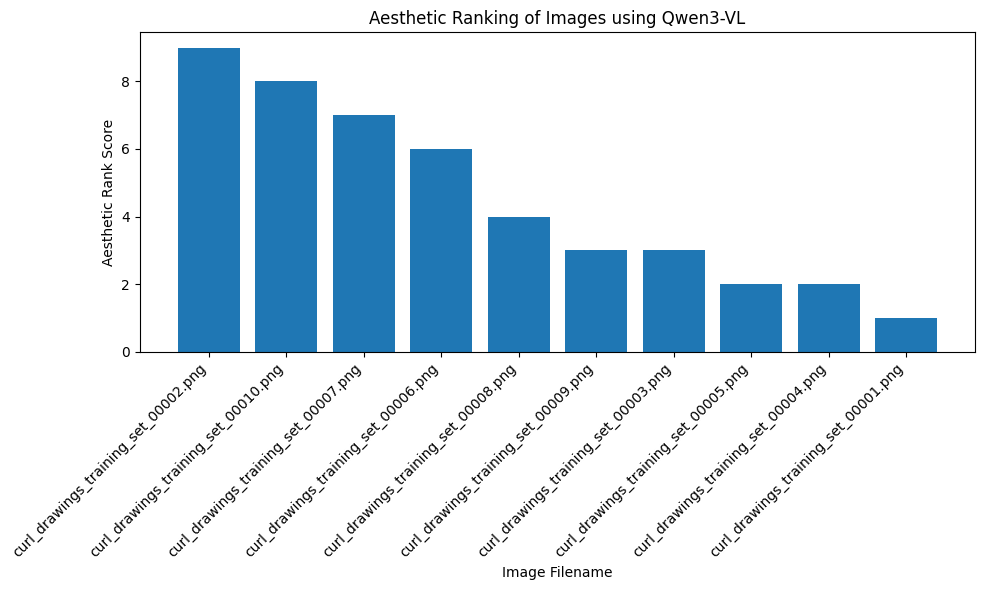

In [37]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(range(n), ranks[sorted_idx], tick_label=filenames[sorted_idx])
ax.set_xlabel("Image Filename")
ax.set_ylabel("Aesthetic Rank Score")
ax.set_title("Aesthetic Ranking of Images using Qwen3-VL")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

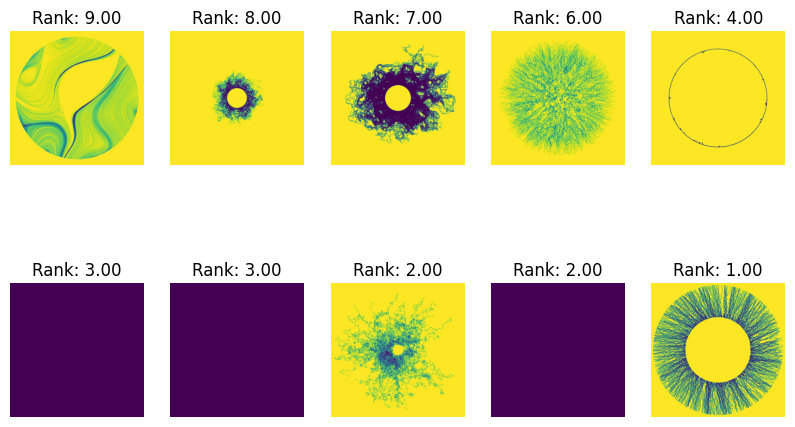

In [42]:
fig, ax = plt.subplots(nrows=2, ncols=5, figsize=(10, 6))
for i in range(2):
    for j in range(5):
        idx = sorted_idx[i * 5 + j]
        img = plt.imread(os.path.join("curl_noise_03", filenames[idx]))
        ax[i, j].imshow(img)
        ax[i, j].set_title(f"Rank: {ranks[idx]:.2f}")
        ax[i, j].axis('off')